# DeltaXRDbench dataset explorer

This notebook previews the three DeltaXRDbench datasets: **MP500**, **RRUFF**, and **opXRD**. For every dataset it displays two single-phase and two multi-phase examples. Each example includes its XRD pattern and reference crystal structure(s).

> Dataset archives must be downloaded from GitHub Releases and extracted under `datasets/` before running this notebook.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms
from IPython.display import Markdown, display

DATASETS = ("mp500", "rruff", "opxrd")
SAMPLES_PER_MODE = 2
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "datasets"
FIG_DIR = PROJECT_ROOT / "figs"

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.6,
    "savefig.dpi": 600,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
})

missing = [name for name in DATASETS if not (DATA_ROOT / name / "patterns.h5").is_file()]
if missing:
    raise FileNotFoundError(
        f"Missing dataset archives: {', '.join(missing)}. Download them from "
        "https://github.com/Asterbin/xrdbench/releases and extract them under datasets/."
    )

FIG_DIR.mkdir(exist_ok=True)
print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Article figures: {FIG_DIR.resolve()}")


Dataset root: /Users/jacob/Documents/GitHub/xrdbench/datasets
Article figures: /Users/jacob/Documents/GitHub/xrdbench/figs


In [2]:
def load_manifest(dataset_root: Path) -> list[dict]:
    with (dataset_root / "manifest.jsonl").open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def get_pattern(dataset_root: Path, record: dict):
    location = record["input"]
    with h5py.File(dataset_root / location["archive"], "r") as h5:
        return h5["two_theta_deg"][:], h5[location["dataset"]][location["index"]]


def get_structure_paths(dataset_root: Path, record: dict) -> list[Path]:
    return [dataset_root / path for path in record["ground_truth"]["structure_files"]]


def _save(figure, stem: str) -> None:
    """Save one publication-ready PNG panel."""
    figure.savefig(FIG_DIR / f"{stem}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)


def _style_xrd(axis) -> None:
    """Style an XRD panel with labelled axes."""
    axis.set_facecolor("white")
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_linewidth(0.6)
    axis.spines["bottom"].set_linewidth(0.6)
    axis.set_xlabel(r"2θ (degrees)")
    axis.set_ylabel("normalized intensity")
    axis.tick_params(which="both", direction="out", width=0.6, length=3)


def save_sample_panels(dataset_name: str, dataset_root: Path, record: dict) -> list[Path]:
    """Export labelled XRD and unlabeled structure panels separately."""
    sample_id = record["sample_id"]
    prefix = sample_id
    written = []

    two_theta, intensity = get_pattern(dataset_root, record)
    figure, axis = plt.subplots(figsize=(3.35, 2.25))
    axis.plot(two_theta, intensity, color="#1F4E79", linewidth=0.9, solid_capstyle="round")
    axis.margins(x=0, y=0.04)
    _style_xrd(axis)
    stem = f"{prefix}_xrd"
    _save(figure, stem)
    display(figure)
    plt.close(figure)
    written.append(FIG_DIR / f"{stem}.png")

    phase_ids = record["ground_truth"]["phase_ids"]
    for phase_id, structure_path in zip(phase_ids, get_structure_paths(dataset_root, record)):
        atoms = read(structure_path)
        figure, axis = plt.subplots(figsize=(2.25, 2.25))
        plot_atoms(atoms, ax=axis, rotation=("35x,25y,10z"), radii=0.55, show_unit_cell=2)
        axis.set_axis_off()
        stem = f"{prefix}_{phase_id}"
        _save(figure, stem)
        display(figure)
        plt.close(figure)
        written.append(FIG_DIR / f"{stem}.png")

    return written


def show_sample(dataset_name: str, dataset_root: Path, record: dict) -> None:
    """Export PNG panels and display them in the notebook."""
    written = save_sample_panels(dataset_name, dataset_root, record)
    display(Markdown(f"Exported `{len(written)}` panels for `{record['sample_id']}`."))


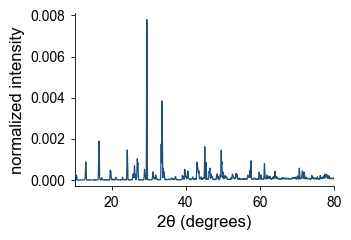

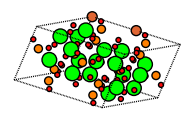

Exported panels for `mp500-single-000000`.

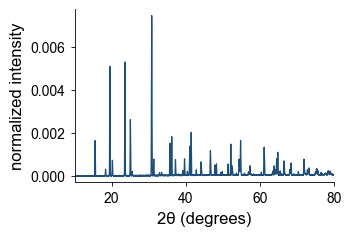

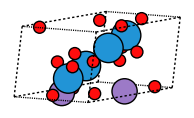

Exported panels for `mp500-single-000001`.

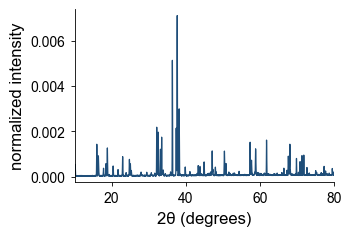

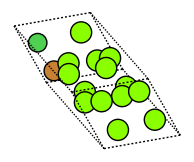

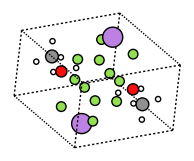

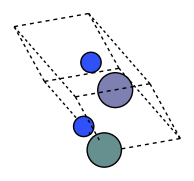

Exported panels for `mp500-multi-000000`.

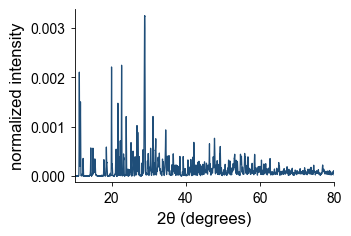

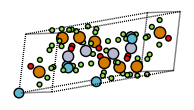

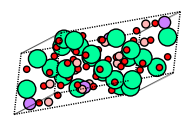

Exported panels for `mp500-multi-000001`.

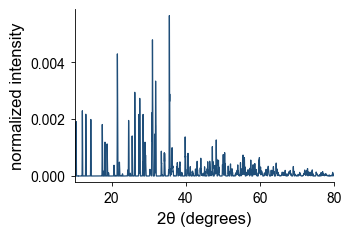

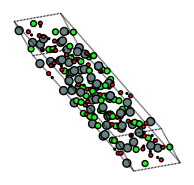

Exported panels for `rruff-single-000000`.

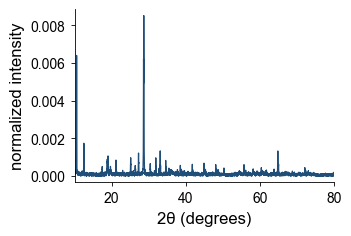

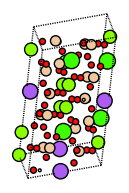

Exported panels for `rruff-single-000001`.

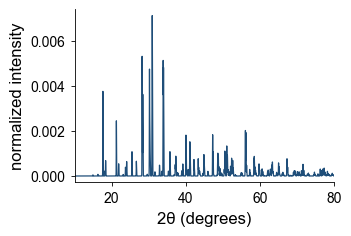

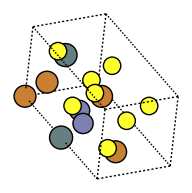

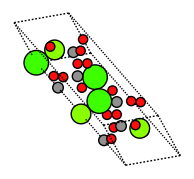

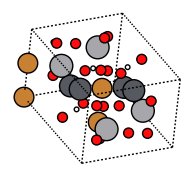

Exported panels for `rruff-multi-000000`.

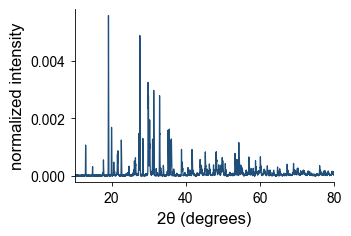

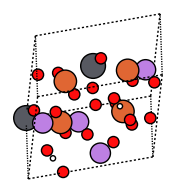

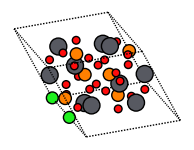

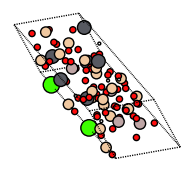

Exported panels for `rruff-multi-000001`.

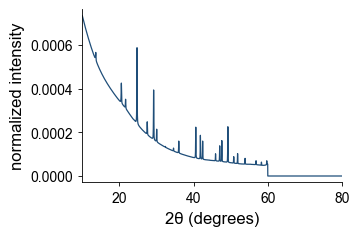

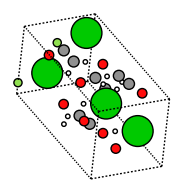

Exported panels for `opxrd-single-000000`.

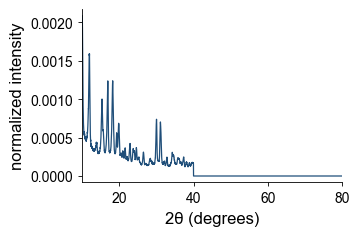

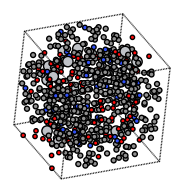

Exported panels for `opxrd-single-000001`.

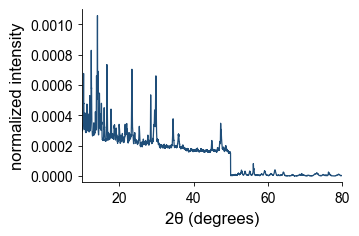

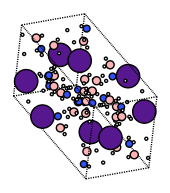

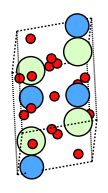

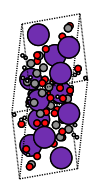

Exported panels for `opxrd-multi-000000`.

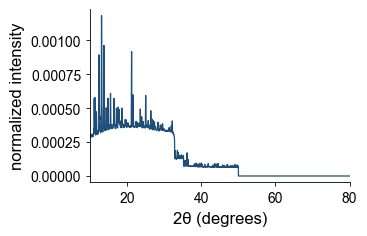

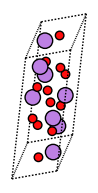

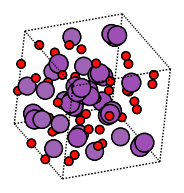

Exported panels for `opxrd-multi-000001`.

Saved 34 PNG panels in /Users/jacob/Documents/GitHub/xrdbench/figs.


In [3]:
written = []
for dataset_name in DATASETS:
    dataset_root = DATA_ROOT / dataset_name
    manifest = load_manifest(dataset_root)
    for task in ("identification.single", "identification.multi"):
        records = [item for item in manifest if item["task"] == task]
        for record in records[:SAMPLES_PER_MODE]:
            written.extend(save_sample_panels(dataset_name, dataset_root, record))
            display(Markdown(f"Exported panels for `{record['sample_id']}`."))

print(f"Saved {len(written)} PNG panels in {FIG_DIR}.")


## Next steps

- Change `SAMPLES_PER_MODE` in the first code cell to display more or fewer examples.
- The displayed phase IDs are internal audit metadata. A model should normally submit CIF files through `prediction.structure_files`, not these IDs.
- See `domo/README.zh-CN.md` for submission.jsonl examples and `docs/GETTING_STARTED.zh-CN.html` for the full user guide.